In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 

In [3]:
WINDOW_SIZE = 1000      # 8 seconds at 125 Hz
STEP_SIZE = 500         # 50% overlap

In [4]:
from scipy.signal import find_peaks
def extract_bp_from_abp(abp):

    # Detect systolic peaks
    peaks, _ = find_peaks(
        abp,
        distance=50,      # minimum distance between peaks
        prominence=5
    )

    if len(peaks) < 3:
        return None, None


    # Systolic values
    sbp_values = abp[peaks]


    # Diastolic values between beats
    dbp_values = []

    for i in range(len(peaks)-1):

        beat = abp[peaks[i]:peaks[i+1]]

        if len(beat) > 0:
            dbp_values.append(np.min(beat))


    if len(dbp_values) == 0:
        return None, None


    sbp = np.median(sbp_values)
    dbp = np.median(dbp_values)


    return sbp, dbp

In [5]:
def process_recording(recording):

    data = recording[:]


    # -------------------------
    # Extract channels
    # -------------------------

    ppg = data[:,0]
    abp = data[:,1]


    # -------------------------
    # Extract BP targets
    # -------------------------

    sbp, dbp = extract_bp_from_abp(abp)


    if sbp is None:
        return None, None


    # -------------------------
    # Normalize PPG
    # -------------------------

    ppg = (ppg - np.mean(ppg)) / np.std(ppg)


    X = []
    y = []


    # -------------------------
    # Windowing
    # -------------------------

    for start in range(
        0,
        len(ppg)-WINDOW_SIZE,
        STEP_SIZE
    ):

        window = ppg[start:start+WINDOW_SIZE]
    

        if len(window)==WINDOW_SIZE:

            X.append(window)

            y.append(
                [sbp, dbp]
            )
    if len(X)==0:
        return None, None


    return np.array(X), np.array(y)

In [6]:
def process_part(file_path, part_name):

    X_all = []
    y_all = []


    with h5py.File(file_path,'r') as f:


        part = f[part_name]


        print(
            "Number of recordings:",
            part.shape[0]
        )


        for i in tqdm(range(part.shape[0])):


            try:

                ref = part[i,0]

                recording = f[ref]


                X,y = process_recording(recording)


                if X is not None:

                    X_all.append(X)
                    y_all.append(y)


            except Exception as e:
                print(
                    "Skipping",
                    i,
                    e
                )

    if len(X_all)==0:
        return None, None


    X_all = np.concatenate(
        X_all,
        axis=0
    )

    y_all = np.concatenate(
        y_all,
        axis=0
    )


    return X_all, y_all

In [7]:
X1,y1 = process_part(
    "../UCI/data/Part_1.mat",
    "Part_1"
)


print(X1.shape)
print(y1.shape)

Number of recordings: 3000


100%|██████████| 3000/3000 [00:16<00:00, 178.65it/s]


(159548, 1000)
(159548, 2)


In [8]:
X_parts = [X1]
y_parts = [y1]

for i in range(2,5):

    print(f"\nProcessing Part_{i}")

    Xi, yi = process_part(
        f"../UCI/data/Part_{i}.mat",
        f"Part_{i}"
    )

    print("X shape:", Xi.shape)
    print("y shape:", yi.shape)

    X_parts.append(Xi)
    y_parts.append(yi)


Processing Part_2
Number of recordings: 3000


100%|██████████| 3000/3000 [00:21<00:00, 141.57it/s]


X shape: (184692, 1000)
y shape: (184692, 2)

Processing Part_3
Number of recordings: 3000


100%|██████████| 3000/3000 [00:16<00:00, 181.44it/s]


X shape: (136156, 1000)
y shape: (136156, 2)

Processing Part_4
Number of recordings: 3000


100%|██████████| 3000/3000 [00:19<00:00, 151.40it/s]


X shape: (162984, 1000)
y shape: (162984, 2)


In [9]:
X = np.concatenate(
    X_parts,
    axis=0
)

y = np.concatenate(
    y_parts,
    axis=0
)


print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (643380, 1000)
Final y shape: (643380, 2)


In [10]:
print("NaN in X:", np.isnan(X).sum())
print("NaN in y:", np.isnan(y).sum())

print("Inf in X:", np.isinf(X).sum())
print("Inf in y:", np.isinf(y).sum())

NaN in X: 0
NaN in y: 0
Inf in X: 0
Inf in y: 0


In [11]:
print("SBP range:")
print(y[:,0].min(), y[:,0].max())

print("\nDBP range:")
print(y[:,1].min(), y[:,1].max())

SBP range:
69.06556344116484 196.47071695400052

DBP range:
50.26078895748954 160.46294684677108


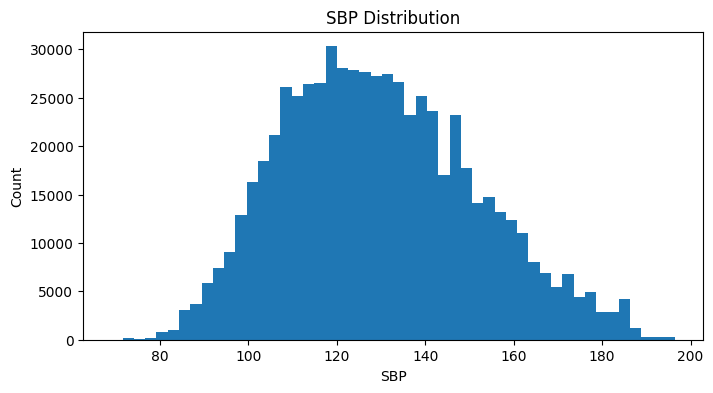

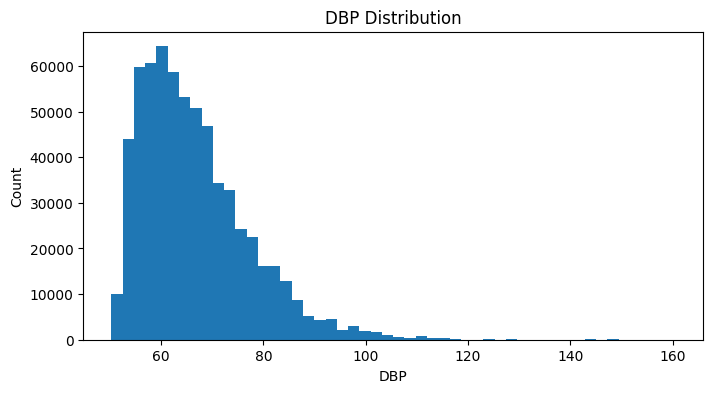

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(y[:,0], bins=50)
plt.xlabel("SBP")
plt.ylabel("Count")
plt.title("SBP Distribution")
plt.show()


plt.figure(figsize=(8,4))
plt.hist(y[:,1], bins=50)
plt.xlabel("DBP")
plt.ylabel("Count")
plt.title("DBP Distribution")
plt.show()

In [13]:
X = X[:, None, :]

print(X.shape)

(643380, 1, 1000)


In [14]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(463233, 1, 1000)
(51471, 1, 1000)
(128676, 1, 1000)


In [15]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val   = torch.tensor(y_val, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)


print(X_train.shape)
print(y_train.shape)

torch.Size([463233, 1, 1000])
torch.Size([463233, 2])


In [16]:
from torch.utils.data import Dataset, DataLoader


class PPGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [17]:
train_dataset = PPGDataset(
    X_train,
    y_train
)

val_dataset = PPGDataset(
    X_val,
    y_val
)

test_dataset = PPGDataset(
    X_test,
    y_test
)

In [18]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([64, 1, 1000])
torch.Size([64, 2])


In [20]:
from models.CNN1D import CNN1D


model = CNN1D()

criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [22]:
model = model.to(device)

In [23]:
EPOCHS = 50

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    # -----------------
    # Training
    # -----------------

    model.train()

    running_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        # Forward
        predictions = model(X_batch)


        # Loss
        loss = criterion(
            predictions,
            y_batch
        )


        # Backprop
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)



    # -----------------
    # Validation
    # -----------------

    model.eval()

    val_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            loss = criterion(
                predictions,
                y_batch
            )


            val_loss += loss.item()


    val_loss = val_loss / len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/50 Train Loss: 1675.8235 Val Loss: 254.2048
Epoch 2/50 Train Loss: 397.0350 Val Loss: 278.6258
Epoch 3/50 Train Loss: 369.3480 Val Loss: 232.4079
Epoch 4/50 Train Loss: 358.5733 Val Loss: 245.7118
Epoch 5/50 Train Loss: 353.1758 Val Loss: 226.7182
Epoch 6/50 Train Loss: 349.2795 Val Loss: 280.9903
Epoch 7/50 Train Loss: 344.9595 Val Loss: 240.6247
Epoch 8/50 Train Loss: 340.6792 Val Loss: 248.6651
Epoch 9/50 Train Loss: 338.8362 Val Loss: 219.0070
Epoch 10/50 Train Loss: 334.1734 Val Loss: 219.1532
Epoch 11/50 Train Loss: 331.3663 Val Loss: 235.2353
Epoch 12/50 Train Loss: 330.6134 Val Loss: 226.1170
Epoch 13/50 Train Loss: 328.1104 Val Loss: 223.1128
Epoch 14/50 Train Loss: 326.9271 Val Loss: 253.0582
Epoch 15/50 Train Loss: 325.6218 Val Loss: 215.1282
Epoch 16/50 Train Loss: 324.1570 Val Loss: 217.5153
Epoch 17/50 Train Loss: 321.8494 Val Loss: 228.0242
Epoch 18/50 Train Loss: 320.2533 Val Loss: 217.6529
Epoch 19/50 Train Loss: 318.6985 Val Loss: 218.9923
Epoch 20/50 Train Lo

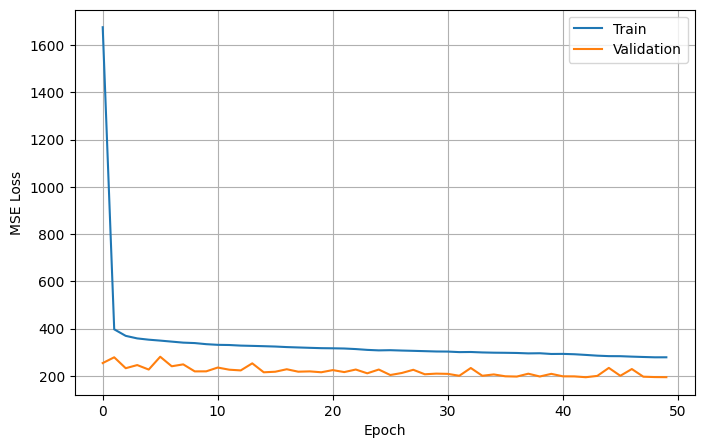

In [24]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (128676, 2)
Targets shape: (128676, 2)


In [26]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 13.47 mmHg
DBP MAE: 6.76 mmHg


In [27]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 17.36 mmHg
DBP RMSE: 9.22 mmHg


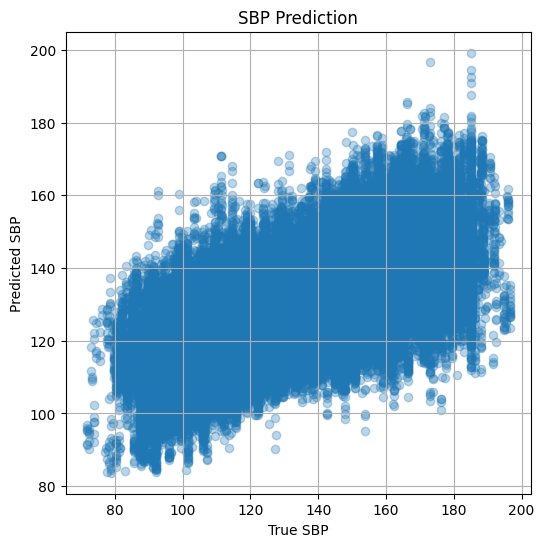

In [28]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

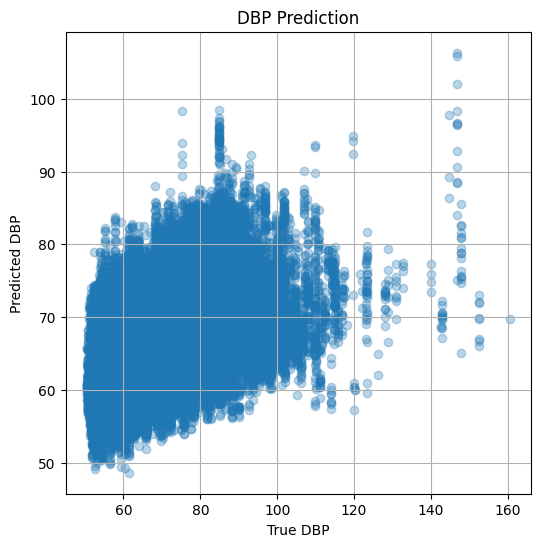

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()

In [30]:
EPOCHS = 100

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    # -----------------
    # Training
    # -----------------

    model.train()

    running_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        # Forward
        predictions = model(X_batch)


        # Loss
        loss = criterion(
            predictions,
            y_batch
        )


        # Backprop
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)



    # -----------------
    # Validation
    # -----------------

    model.eval()

    val_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            loss = criterion(
                predictions,
                y_batch
            )


            val_loss += loss.item()


    val_loss = val_loss / len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/100 Train Loss: 277.5913 Val Loss: 272.4781
Epoch 2/100 Train Loss: 275.8620 Val Loss: 214.9142
Epoch 3/100 Train Loss: 275.6591 Val Loss: 204.0589
Epoch 4/100 Train Loss: 275.2478 Val Loss: 200.3919
Epoch 5/100 Train Loss: 273.3637 Val Loss: 189.7326
Epoch 6/100 Train Loss: 273.3598 Val Loss: 192.2503
Epoch 7/100 Train Loss: 272.0598 Val Loss: 195.5593
Epoch 8/100 Train Loss: 271.6528 Val Loss: 197.9269
Epoch 9/100 Train Loss: 270.4591 Val Loss: 189.2953
Epoch 10/100 Train Loss: 270.1244 Val Loss: 191.6943
Epoch 11/100 Train Loss: 269.4458 Val Loss: 186.6134
Epoch 12/100 Train Loss: 267.7139 Val Loss: 187.0866
Epoch 13/100 Train Loss: 267.7762 Val Loss: 186.5977
Epoch 14/100 Train Loss: 265.9513 Val Loss: 218.8159
Epoch 15/100 Train Loss: 265.8850 Val Loss: 194.8348
Epoch 16/100 Train Loss: 265.1362 Val Loss: 235.9265
Epoch 17/100 Train Loss: 264.8720 Val Loss: 193.1045
Epoch 18/100 Train Loss: 264.5889 Val Loss: 184.3102
Epoch 19/100 Train Loss: 262.9049 Val Loss: 199.7150
Ep

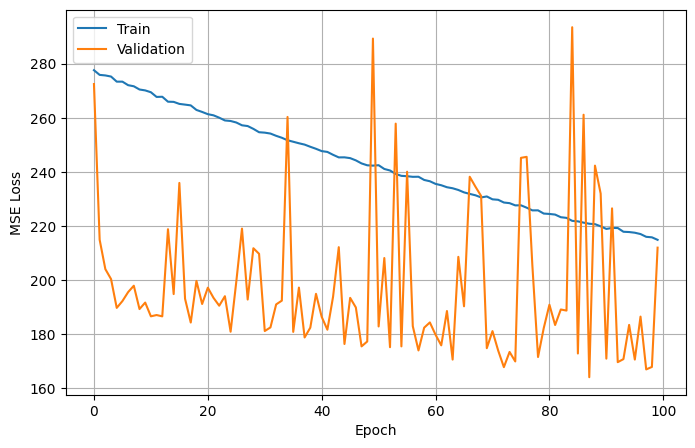

In [31]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [32]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (128676, 2)
Targets shape: (128676, 2)


In [33]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 14.45 mmHg
DBP MAE: 6.45 mmHg


In [34]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 18.48 mmHg
DBP RMSE: 9.02 mmHg


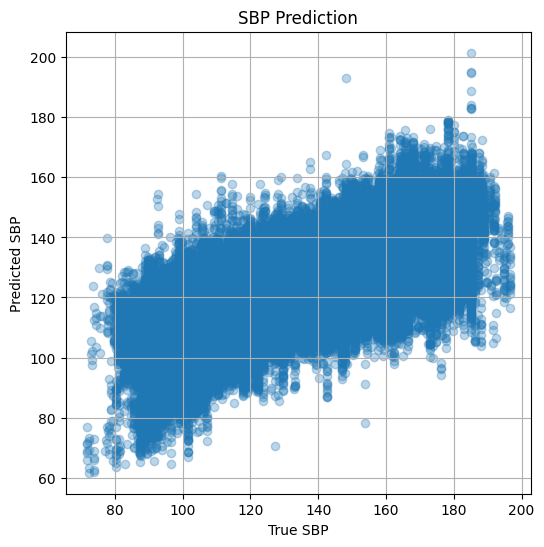

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

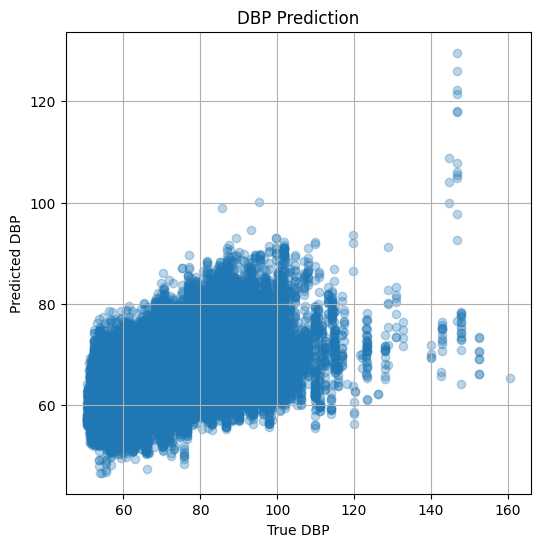

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()